## Preprocessing

In [1]:
import os
import re

folder = "/home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/outputs_t1_S2"

# Match ANY prefix, then a 7-digit number, then underscore + digits + .tif
pattern = re.compile(r"^(.*_)(\d{7})(_\d+\.tif)$")

for fname in os.listdir(folder):
    if not fname.endswith(".tif"):
        continue

    m = pattern.match(fname)
    if not m:
        continue

    prefix = m.group(1)     # everything before first 7-digit block
    num1   = int(m.group(2))
    suffix = m.group(3)     # everything after it

    # Add 50 and keep 7 digits
    new_num1 = f"{num1 + 50:07d}"

    new_name = f"{prefix}{new_num1}{suffix}"

    old_path = os.path.join(folder, fname)
    new_path = os.path.join(folder, new_name)

    # Rename (this modifies the original file, no new file created)
    os.rename(old_path, new_path)

    print(f"Renamed: {fname}  →  {new_name}")


Renamed: time_of_arrival_0000008_0129613.tif  →  time_of_arrival_0000058_0129613.tif
Renamed: time_of_arrival_0000029_0129606.tif  →  time_of_arrival_0000079_0129606.tif
Renamed: time_of_arrival_0000038_0129601.tif  →  time_of_arrival_0000088_0129601.tif
Renamed: ember_flux_0000026_0129613.tif  →  ember_flux_0000076_0129613.tif
Renamed: flame_length_0000024_0129609.tif  →  flame_length_0000074_0129609.tif
Renamed: flame_length_0000040_0129608.tif  →  flame_length_0000090_0129608.tif
Renamed: ember_flux_0000001_0129601.tif  →  ember_flux_0000051_0129601.tif
Renamed: time_of_arrival_0000015_0129601.tif  →  time_of_arrival_0000065_0129601.tif
Renamed: time_of_arrival_0000001_0129601.tif  →  time_of_arrival_0000051_0129601.tif
Renamed: ember_flux_0000010_0129602.tif  →  ember_flux_0000060_0129602.tif
Renamed: flame_length_0000020_0129610.tif  →  flame_length_0000070_0129610.tif
Renamed: time_of_arrival_0000044_0129602.tif  →  time_of_arrival_0000094_0129602.tif
Renamed: time_of_arrival_000

## Tubbs Revalidation

### TOA Histogram

In [2]:
import os
import glob
import shutil


mainFolder = r"/home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y"

# Path to the "post" folder
post_folder = os.path.join(mainFolder, "post")

# Create folder if it doesn't exist
os.makedirs(post_folder, exist_ok=True)

# Find all time_*.tif files in mainFolder (non-recursive)
tif_files = glob.glob(os.path.join(mainFolder, "time_*.tif"))

# Move them to the post folder
for tif_file in tif_files:
    shutil.move(tif_file, post_folder)

In [3]:
print (mainFolder)

/home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y


In [4]:
folder = rf"{mainFolder}/post"
pattern = os.path.join(folder, "*.tif")

for filepath in glob.glob(pattern):
    dirname, filename = os.path.split(filepath)
    name, ext = os.path.splitext(filename)
    
    if len(name) >= 7:
        # Remove last 7 chars, add '0086400'
        new_name = name[:-7] + "0129600"
        new_filepath = os.path.join(dirname, new_name + ext)
        
        if new_filepath != filepath:
            print(f"Renaming:\n  {filename} -> {new_name + ext}")
            os.rename(filepath, new_filepath)
    else:
        print(f"Skipping {filename} (filename too short)")

Renaming:
  time_of_arrival_0000029_0129601.tif -> time_of_arrival_0000029_0129600.tif
Renaming:
  time_of_arrival_0000040_0129601.tif -> time_of_arrival_0000040_0129600.tif
Renaming:
  time_of_arrival_0000086_0129602.tif -> time_of_arrival_0000086_0129600.tif
Renaming:
  time_of_arrival_0000001_0129601.tif -> time_of_arrival_0000001_0129600.tif
Renaming:
  time_of_arrival_0000062_0129613.tif -> time_of_arrival_0000062_0129600.tif
Renaming:
  time_of_arrival_0000096_0129606.tif -> time_of_arrival_0000096_0129600.tif
Renaming:
  time_of_arrival_0000006_0129602.tif -> time_of_arrival_0000006_0129600.tif
Renaming:
  time_of_arrival_0000036_0129602.tif -> time_of_arrival_0000036_0129600.tif
Renaming:
  time_of_arrival_0000039_0129602.tif -> time_of_arrival_0000039_0129600.tif
Renaming:
  time_of_arrival_0000044_0129601.tif -> time_of_arrival_0000044_0129600.tif
Renaming:
  time_of_arrival_0000058_0129613.tif -> time_of_arrival_0000058_0129600.tif
Renaming:
  time_of_arrival_0000094_0129602

In [5]:
# Step 2: Run the raster_percentile_p.py script on the same folder
!python raster_percentile_p.py --root_dir "{folder}" --output_types time_of_arrival --percentile_vals 50 90

Root Directory: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/post
Output Types: ['time_of_arrival']
Percentile Value: [50, 90]
Processing time_of_arrival in time bucket 129600
Processing complete for /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/post
Processing task: ('/home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/post', ['time_of_arrival'], [50, 90])


In [6]:
import os
import rasterio
import numpy as np
from rasterio.features import shapes
import geopandas as gpd
from shapely.geometry import shape

# Paths
parent_folder = os.path.dirname(folder)  # one level up from your current folder
structure_points_folder = os.path.join(parent_folder, "structurePoints")
os.makedirs(structure_points_folder, exist_ok=True)  # create folder if it doesn't exist

raster_path = os.path.join(parent_folder, "fbfm40b.tif")
output_shp_path = os.path.join(structure_points_folder, "fbfm40_mask.shp")

# Step 1: Load raster and null pixels != 91
with rasterio.open(raster_path) as src:
    data = src.read(1)
    profile = src.profile

    # Mask all pixels not equal to 91 (set them to nodata)
    masked_data = np.where(data == 91, data, profile['nodata'] if profile['nodata'] is not None else 0)
    
    # Update profile for masked raster if nodata is not set
    if profile['nodata'] is None:
        profile.update(nodata=0)

# Optional: save masked raster (if you want)
masked_raster_path = os.path.join(structure_points_folder, "fbfm40_masked.tif")
with rasterio.open(masked_raster_path, "w", **profile) as dst:
    dst.write(masked_data, 1)

# Step 2: Convert masked raster to shapefile polygons where data == 91
mask = masked_data != profile['nodata']

results = (
    {'properties': {'value': v}, 'geometry': s}
    for i, (s, v) in enumerate(shapes(masked_data, mask=mask, transform=src.transform))
    if v == 91
)

geoms = list(results)
if geoms:
    gdf = gpd.GeoDataFrame.from_features(geoms, crs=src.crs)
    gdf.to_file(output_shp_path)
    print(f"Shapefile saved to {output_shp_path}")
else:
    print("No polygons found with value 91")


Shapefile saved to /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/structurePoints/fbfm40_mask.shp


In [14]:
!pip install seaborn

Heli
Raster loaded from /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/post/post-processed/time_of_arrival_pct_90_time_129600.tif with shape: (1476, 1457) and NoData value: -9999.0
CRS mismatch. Reprojecting structures to match raster CRS...


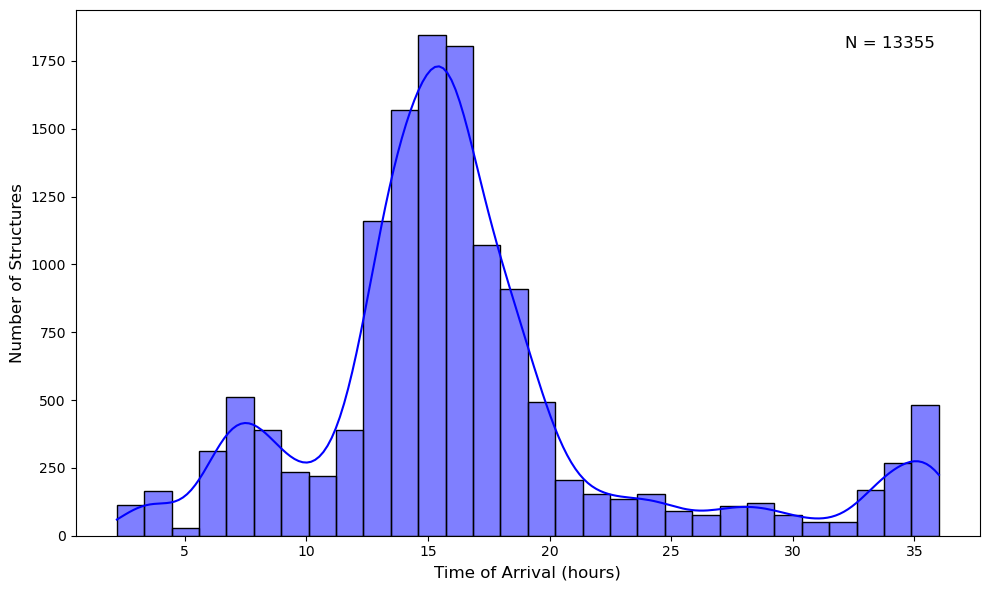

Helu


In [7]:
import rasterio
import geopandas as gpd
import numpy as np
from rasterio.features import rasterize
import matplotlib.pyplot as plt
import seaborn as sns

# Paths to files
# toa_files = {
#     'tubbs': r"/home/dwip/elmfire/runs/REVALIDATION/THOMAS/thomas_SOTA/post/post-processed/time_of_arrival_pct_50_time_61200.tif",
# }

toa_files = {
    'tubbs': glob.glob(
        os.path.join(mainFolder, "post", "post-processed", "*_pct_*.tif")
    )[0]
}
    
structures_gdf = gpd.read_file(r"/home/dwip/elmfire/runs/REVALIDATION/CAMP/Camp_final")

print ("Heli")

# Function to load and extract TOA values for structures
def load_and_extract_toa_values(toa_file, structures_gdf):
    with rasterio.open(toa_file) as src:
        toa_data = src.read(1)
        transform = src.transform
        nodata_value = src.nodata

    print(f"Raster loaded from {toa_file} with shape: {toa_data.shape} and NoData value: {nodata_value}")

    # Check CRS alignment for the raster and structures
    if structures_gdf.crs != src.crs:
        print("CRS mismatch. Reprojecting structures to match raster CRS...")
        structures_gdf = structures_gdf.to_crs(src.crs)

    # Rasterize structure footprints to align with the raster
    structure_mask = rasterize(
        ((geom, 1) for geom in structures_gdf.geometry),
        out_shape=toa_data.shape,
        transform=transform,
        fill=0,
        dtype='int32'
    )

    # Extract TOA values where structures exist
    structure_toa_values = toa_data[structure_mask == 1]
    
    # Filter out NoData and zero values
    if nodata_value is not None:
        structure_toa_values = structure_toa_values[structure_toa_values != nodata_value]
    structure_toa_values = structure_toa_values[structure_toa_values > 0]

    return structure_toa_values

# Load TOA values
toa_file = toa_files['tubbs']
structure_toa_values = load_and_extract_toa_values(toa_file, structures_gdf)

# Convert TOA values from seconds to hours
structure_toa_values_hours = structure_toa_values / 3600

# Plot histogram with KDE
plt.figure(figsize=(10, 6))
sns.histplot(structure_toa_values_hours, kde=True, color="blue", bins=30)

# Add labels and title
plt.xlabel("Time of Arrival (hours)", fontsize=12)
plt.ylabel("Number of Structures", fontsize=12)

# Add total number of structures (N) to the plot
n_structures = len(structure_toa_values_hours)
plt.text(
    0.95, 0.95, f"N = {n_structures}",
    fontsize=12, color="black", transform=plt.gca().transAxes,
    horizontalalignment="right", verticalalignment="top"
)

# Get last folder name
last_name = os.path.basename(mainFolder.rstrip("/"))

result_dir = os.path.join(mainFolder, "RESULTS")
os.makedirs(result_dir, exist_ok=True)

RESULT_folder = result_dir

# Build full output path
outfile = os.path.join(result_dir, f"{last_name}.jpg")

# Show the plot
# Save histograms
plt.tight_layout()

plt.savefig(outfile, dpi=300, bbox_inches="tight")  # save to file

plt.show()

print ("Helu")


### Global Similarity

In [35]:
# mainFolder = r"/home/dwip/elmfire/runs/REVALIDATION/TUBBS/outputsTubbs_DIFFUSIVE"

In [8]:
import os

POST_folder = os.path.join(mainFolder, "post")
NULL_folder = os.path.join(POST_folder, "NULL") 
POLY_folder = os.path.join(NULL_folder, "POLYGONS")  # output folder for shapefiles
groundTruth_folder = os.path.join(os.path.dirname(mainFolder), "groundTruth")
RESULT_folder = os.path.join(mainFolder, "RESULTS")

print(RESULT_folder)


/home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/RESULTS


In [9]:
import pandas as pd
import os

# Paths
s1_file = os.path.join(mainFolder, "outputs_t1_S1", "fire_size_stats.csv")
s2_file = os.path.join(mainFolder, "outputs_t1_S2", "fire_size_stats.csv")

# Load CSVs
df1 = pd.read_csv(s1_file)
df2 = pd.read_csv(s2_file)

# The numbering column is **Fire id**
index_col = "Fire id"

# Fix numbering of S2 so it continues after S1
max_id = df1[index_col].max()
df2[index_col] = df2[index_col] + max_id

# Combine vertically (S1 on top, S2 bottom)
combined = pd.concat([df1, df2], ignore_index=True)

# Save output
output_file = os.path.join(mainFolder, "fire_size_stats.csv") 
combined.to_csv(output_file, index=False)

print("Combined file saved to:", output_file)

Combined file saved to: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/fire_size_stats.csv


In [10]:
import os
import pandas as pd
import numpy as np
import glob
import shutil

# -----------------------------------------
# 1. Load combined fire stat CSV
# -----------------------------------------
firestat_file = os.path.join(mainFolder, "fire_size_stats.csv") 
src_folder = POST_folder
dst_folder = RESULT_folder




df = pd.read_csv(firestat_file)


col7 = "Total fire area (ac)"
last_col = "Fire id"



# -----------------------------------------
# 2. 7th column = Total fire area (ac)
# -----------------------------------------
# col7 = df.columns[6]  # 0-based index: 6 = 7th column

values7 = df[col7].values

# -----------------------------------------
# 3. Compute median
# -----------------------------------------
median_value = np.median(values7)
print("Median Total Fire Area (7th column):", median_value)

# -----------------------------------------
# 4. Select row with value closest to median
# -----------------------------------------
df["dist_to_median"] = np.abs(df[col7] - median_value)
row = df.loc[df["dist_to_median"].idxmin()]   # best match

print("Closest row value:", row[col7])

# -----------------------------------------
# 5. Use last-column value for TIFF selection
# -----------------------------------------
# last_col = df.columns[-1]


tif_key_value = int(row[last_col])
tif_key_str = f"{tif_key_value:07d}"

print("TIFF key (from last column):", tif_key_str)

# -----------------------------------------
# 6. Find matching TIFF
# -----------------------------------------

pattern = os.path.join(src_folder, f"time_of_arrival_{tif_key_str}_*.tif")

matching_files = glob.glob(pattern)

if not matching_files:
    raise RuntimeError(f"No TIFF found for key {tif_key_str}")

tif_file = matching_files[0]
print("Found TIFF:", tif_file)

# -----------------------------------------
# 7. Copy to RESULTS folder
# -----------------------------------------

dst_path = os.path.join(dst_folder, os.path.basename(tif_file))

shutil.copy(tif_file, dst_path)

print("✅ Copied to:", dst_path)

Median Total Fire Area (7th column): 165742.9
Closest row value: 165748.8
TIFF key (from last column): 0000032
Found TIFF: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/post/time_of_arrival_0000032_0129600.tif
✅ Copied to: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/RESULTS/time_of_arrival_0000032_0129600.tif


In [11]:
import os
import shutil
import rasterio
import numpy as np

# ---------------------------
# Paths
# ---------------------------
in_folder = POST_folder  #os.path.join(mainFolder, "post") #r"/home/dwip/elmfire/runs/REVALIDATION/TUBBS/outputs_Tubbs_SOTA_UNI/post"
out_folder = NULL_folder  #os.path.join(in_folder, "NULL")  # output folder

# ---------------------------
# Check/create output folder
# ---------------------------
if os.path.exists(out_folder):
    shutil.rmtree(out_folder)   # delete existing folder
os.makedirs(out_folder)         # create new folder

# ---------------------------
# List all TIFF files
# ---------------------------
files = [f for f in os.listdir(in_folder) if f.endswith(".tif")]
print(f"Found {len(files)} rasters:", files)

# ---------------------------
# Process each raster
# ---------------------------
for f in files:
    in_file = os.path.join(in_folder, f)
    out_file = os.path.join(out_folder, f)

    with rasterio.open(in_file) as src:
        data = src.read(1)  # read first band
        profile = src.profile

    # ---------------------------
    # SetNull equivalent: set all pixels <0 to 0 or np.nan
    # In your ArcPy code you used "1" as the output value where condition is false
    # Here we do the same: pixels <0 -> nodata, pixels >=0 -> 1
    # ---------------------------
    out_data = np.where(data < 0, src.nodata if src.nodata is not None else 0, 1)

    # Save output
    with rasterio.open(out_file, "w", **profile) as dst:
        dst.write(out_data, 1)

    print(f"✅ Processed raster: {f} → {out_file}")


Found 100 rasters: ['time_of_arrival_0000068_0129600.tif', 'time_of_arrival_0000058_0129600.tif', 'time_of_arrival_0000004_0129600.tif', 'time_of_arrival_0000054_0129600.tif', 'time_of_arrival_0000037_0129600.tif', 'time_of_arrival_0000091_0129600.tif', 'time_of_arrival_0000012_0129600.tif', 'time_of_arrival_0000059_0129600.tif', 'time_of_arrival_0000048_0129600.tif', 'time_of_arrival_0000045_0129600.tif', 'time_of_arrival_0000081_0129600.tif', 'time_of_arrival_0000040_0129600.tif', 'time_of_arrival_0000017_0129600.tif', 'time_of_arrival_0000083_0129600.tif', 'time_of_arrival_0000078_0129600.tif', 'time_of_arrival_0000100_0129600.tif', 'time_of_arrival_0000096_0129600.tif', 'time_of_arrival_0000052_0129600.tif', 'time_of_arrival_0000031_0129600.tif', 'time_of_arrival_0000066_0129600.tif', 'time_of_arrival_0000072_0129600.tif', 'time_of_arrival_0000020_0129600.tif', 'time_of_arrival_0000053_0129600.tif', 'time_of_arrival_0000003_0129600.tif', 'time_of_arrival_0000047_0129600.tif', 'time

In [12]:
import os
import shutil
import rasterio
from rasterio.features import shapes
import geopandas as gpd
from shapely.geometry import shape

# ---------------------------
# Input and output folders
# ---------------------------
in_folder = NULL_folder   #r"/home/dwip/elmfire/runs/REVALIDATION/TUBBS/outputs_Tubbs_SOTA_UNI/post/NULL"
out_folder = POLY_folder  #os.path.join(in_folder, "POLYGONS")  # output folder for shapefiles

# ---------------------------
# Check/create output folder
# ---------------------------
if os.path.exists(out_folder):
    shutil.rmtree(out_folder)   # delete existing folder
os.makedirs(out_folder)         # create fresh folder

# ---------------------------
# List all TIFF files in NULL folder
# ---------------------------
files = [f for f in os.listdir(in_folder) if f.endswith(".tif")]
print(f"Found {len(files)} rasters in NULL folder:", files)

# ---------------------------
# Convert each raster to polygons (Shapefile)
# ---------------------------
for f in files:
    in_file = os.path.join(in_folder, f)
    out_file = os.path.join(out_folder, f.replace(".tif", ".shp"))  # save as Shapefile

    with rasterio.open(in_file) as src:
        data = src.read(1)
        transform = src.transform
        crs = src.crs

        # Mask to ignore nodata values
        mask = data != src.nodata if src.nodata is not None else data != 0

        # Extract polygons from raster
        results = (
            {"properties": {"value": int(v)}, "geometry": s}
            for s, v in shapes(data, mask=mask, transform=transform)
        )

        # Build GeoDataFrame
        geoms = [shape(feature["geometry"]) for feature in results]
        values = [feature["properties"]["value"] for feature in results]
        gdf = gpd.GeoDataFrame({"value": values}, geometry=geoms, crs=crs)

        # Save as Shapefile
        gdf.to_file(out_file, driver="ESRI Shapefile")

    print(f"✅ Raster {f} converted to polygons → {out_file}")


Found 100 rasters in NULL folder: ['time_of_arrival_0000068_0129600.tif', 'time_of_arrival_0000058_0129600.tif', 'time_of_arrival_0000004_0129600.tif', 'time_of_arrival_0000054_0129600.tif', 'time_of_arrival_0000037_0129600.tif', 'time_of_arrival_0000091_0129600.tif', 'time_of_arrival_0000012_0129600.tif', 'time_of_arrival_0000059_0129600.tif', 'time_of_arrival_0000048_0129600.tif', 'time_of_arrival_0000045_0129600.tif', 'time_of_arrival_0000081_0129600.tif', 'time_of_arrival_0000040_0129600.tif', 'time_of_arrival_0000017_0129600.tif', 'time_of_arrival_0000083_0129600.tif', 'time_of_arrival_0000078_0129600.tif', 'time_of_arrival_0000100_0129600.tif', 'time_of_arrival_0000096_0129600.tif', 'time_of_arrival_0000052_0129600.tif', 'time_of_arrival_0000031_0129600.tif', 'time_of_arrival_0000066_0129600.tif', 'time_of_arrival_0000072_0129600.tif', 'time_of_arrival_0000020_0129600.tif', 'time_of_arrival_0000053_0129600.tif', 'time_of_arrival_0000003_0129600.tif', 'time_of_arrival_0000047_0129

In [13]:
import os
import shutil
import geopandas as gpd

# ---------------------------
# Input folders
# ---------------------------
poly_folder = POLY_folder  #r"/home/dwip/elmfire/runs/Troubleshooting/tubbs_dwi/ANALYSIS/outputs_Tubbs_INTERMEDIATE_NU/post/NULL/POLYGONS"  # POLYGONS folder
# groundTruth_folder = os.path.join(os.path.dirname(mainFolder), "groundTruth")  #r"/home/dwip/elmfire/runs/Troubleshooting/tubbs_dwi/ANALYSIS/outputs_Tubbs_UNIFORM/post/NULL/groundTruth"

# ---------------------------
# Output folder (parent + KAPPA_ANALYSIS)
# ---------------------------
out_folder = os.path.join(os.path.dirname(poly_folder), "KAPPA_ANALYSIS")
if os.path.exists(out_folder):
    shutil.rmtree(out_folder)
os.makedirs(out_folder)

# ---------------------------
# List input shapefiles
# ---------------------------
# All polygons starting with "time" in POLYGONS folder
all_shp = [f for f in os.listdir(poly_folder) if f.endswith(".shp") and f.startswith("time")]

# Validation and extent shapefiles from groundTruth folder
val_shp = [f for f in os.listdir(groundTruth_folder) if f.endswith("Validation.shp")]
ext_shp = [f for f in os.listdir(groundTruth_folder) if f.endswith("xtent.shp")]

print("All polygons:", all_shp)
print("Validation shapefiles:", val_shp)
print("Extent shapefiles:", ext_shp)

if not val_shp or not ext_shp:
    raise FileNotFoundError("Validation or Extent shapefiles not found!")

val_path = os.path.join(groundTruth_folder, val_shp[0])
ext_path = os.path.join(groundTruth_folder, ext_shp[0])

# ---------------------------
# True Positive, False Positive, False Negative, Merge
# ---------------------------
merge_files = []

val_gdf = gpd.read_file(val_path)

for shp_file in all_shp:
    shp_path = os.path.join(poly_folder, shp_file)
    gdf = gpd.read_file(shp_path)

        # Reproject gdf to match val_gdf CRS
    if gdf.crs != val_gdf.crs:
        gdf = gdf.to_crs(val_gdf.crs)

    # True Positives: intersection
    tPos = gpd.overlay(gdf, val_gdf, how="intersection")
    tPos_file = os.path.join(out_folder, "tPos_" + shp_file)
    tPos.to_file(tPos_file)

    # False Positives: difference
    fPos = gpd.overlay(gdf, val_gdf, how="difference")
    fPos_file = os.path.join(out_folder, "fPos_" + shp_file)
    fPos.to_file(fPos_file)

    # False Negatives: difference
    fNeg = gpd.overlay(val_gdf, gdf, how="difference")
    fNeg_file = os.path.join(out_folder, "fNeg_" + shp_file)
    fNeg.to_file(fNeg_file)

    # Merge: union
    merge = gpd.overlay(gdf, val_gdf, how="union")
    merge_file = os.path.join(out_folder, "Merge_" + shp_file)
    merge.to_file(merge_file)
    merge_files.append(merge_file)

    print(f"✅ Processed {shp_file}")

# ---------------------------
# True Negatives: erase merge from extent
# ---------------------------
ext_gdf = gpd.read_file(ext_path)

for merge_file in merge_files:
    merge_gdf = gpd.read_file(merge_file)

    # Reproject ext_gdf to match merge_gdf CRS
    if ext_gdf.crs != merge_gdf.crs:
        ext_gdf = ext_gdf.to_crs(merge_gdf.crs)
    
    tNeg = gpd.overlay(ext_gdf, merge_gdf, how="difference")
    tNeg_file = os.path.join(out_folder, "tNeg_" + os.path.basename(merge_file)[6:])  # mimic ArcPy naming
    tNeg.to_file(tNeg_file)
    print(f"✅ True Negative saved: {tNeg_file}")


All polygons: ['time_of_arrival_0000018_0129600.shp', 'time_of_arrival_0000017_0129600.shp', 'time_of_arrival_0000077_0129600.shp', 'time_of_arrival_0000027_0129600.shp', 'time_of_arrival_0000034_0129600.shp', 'time_of_arrival_0000064_0129600.shp', 'time_of_arrival_0000089_0129600.shp', 'time_of_arrival_0000022_0129600.shp', 'time_of_arrival_0000019_0129600.shp', 'time_of_arrival_0000055_0129600.shp', 'time_of_arrival_0000082_0129600.shp', 'time_of_arrival_0000002_0129600.shp', 'time_of_arrival_0000057_0129600.shp', 'time_of_arrival_0000029_0129600.shp', 'time_of_arrival_0000099_0129600.shp', 'time_of_arrival_0000076_0129600.shp', 'time_of_arrival_0000028_0129600.shp', 'time_of_arrival_0000024_0129600.shp', 'time_of_arrival_0000009_0129600.shp', 'time_of_arrival_0000073_0129600.shp', 'time_of_arrival_0000088_0129600.shp', 'time_of_arrival_0000050_0129600.shp', 'time_of_arrival_0000047_0129600.shp', 'time_of_arrival_0000100_0129600.shp', 'time_of_arrival_0000039_0129600.shp', 'time_of_a

/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field dateCrnt create as date field, though DateTime requested.
  ogr_write(
/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 442944975.611000001 of field GISACRES of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 442944975.611000001 of field GISACRES of feature 1 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 442944975.611000001 of field GISACRES of feature 2 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site

✅ Processed time_of_arrival_0000018_0129600.shp


/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field dateCrnt create as date field, though DateTime requested.
  ogr_write(
/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 442944975.611000001 of field GISACRES of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 442944975.611000001 of field GISACRES of feature 1 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 442944975.611000001 of field GISACRES of feature 2 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site

✅ Processed time_of_arrival_0000017_0129600.shp


...

✅ Processed time_of_arrival_0000013_0129600.shp


/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field dateCrnt create as date field, though DateTime requested.
  ogr_write(
/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 442944975.611000001 of field GISACRES of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 442944975.611000001 of field GISACRES of feature 1 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 442944975.611000001 of field GISACRES of feature 2 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site

✅ Processed time_of_arrival_0000080_0129600.shp


/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field dateCrnt create as date field, though DateTime requested.
  ogr_write(
/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 442944975.611000001 of field GISACRES of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 442944975.611000001 of field GISACRES of feature 1 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 442944975.611000001 of field GISACRES of feature 2 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site

✅ Processed time_of_arrival_0000079_0129600.shp
✅ True Negative saved: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/post/NULL/KAPPA_ANALYSIS/tNeg_time_of_arrival_0000018_0129600.shp
✅ True Negative saved: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/post/NULL/KAPPA_ANALYSIS/tNeg_time_of_arrival_0000017_0129600.shp
✅ True Negative saved: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/post/NULL/KAPPA_ANALYSIS/tNeg_time_of_arrival_0000077_0129600.shp
✅ True Negative saved: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/post/NULL/KAPPA_ANALYSIS/tNeg_time_of_arrival_0000027_0129600.shp
✅ True Negative saved: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/post/NULL/KAPPA_ANALYSIS/tNeg_time_of_arrival_0000034_0129600.shp
✅ True Negative saved: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/post/NULL/KAPPA_ANALYSIS/tNeg_time_of_arrival_0000064_0129600.shp
✅ True Negative saved:

In [14]:
import os
import geopandas as gpd
import pandas as pd

# ---------------------------
# Input folders
# ---------------------------
poly_folder = POLY_folder  #r"/home/dwip/elmfire/runs/Troubleshooting/tubbs_dwi/ANALYSIS/outputs_Tubbs_INTERMEDIATE_NU/post/NULL/POLYGONS"
parent_folder = os.path.dirname(poly_folder)
kappa_folder = os.path.join(parent_folder, "KAPPA_ANALYSIS")

# ---------------------------
# Output file
# ---------------------------
out_file = os.path.join(RESULT_folder, "AREA_summary_with_similarity.xlsx")

# ---------------------------
# Constants from your description
# ---------------------------
OBSERVATION = 4.43E+08  # $C$33  Tubbs (1.02e8)  Thomas (2.65E+08)  Camp (4.43E+08)
TOTAL_AREA  = 1.94E+09   # $C$34  Tubbs (5.69e8)  Thomas (8.36E+08)  Camp (1.94E+09)

# ---------------------------
# Collect shapefiles
# ---------------------------
a1 = [f for f in os.listdir(poly_folder) if f.endswith(".shp") and f.startswith("time")]
a2 = [f for f in os.listdir(kappa_folder) if f.endswith(".shp") and f.startswith("tPos")]
a3 = [f for f in os.listdir(kappa_folder) if f.endswith(".shp") and f.startswith("tNeg")]
a4 = [f for f in os.listdir(kappa_folder) if f.endswith(".shp") and f.startswith("fPos")]
a5 = [f for f in os.listdir(kappa_folder) if f.endswith(".shp") and f.startswith("fNeg")]

# ---------------------------
# Helper: calculate total area of a shapefile
# ---------------------------
def total_area(shp_path):
    gdf = gpd.read_file(shp_path)
    if gdf.crs.is_geographic:
        gdf = gdf.to_crs(epsg=32611)  # Change to your UTM zone
    return gdf.geometry.area.sum()

# ---------------------------
# Build summary table
# ---------------------------
summary = []

for f in a1:
    ensemble_id = os.path.splitext(f)[0].replace("time", "")  # extract ID from filename
    row = {"ID": ensemble_id}

    # time polygons (D column)
    time_area = total_area(os.path.join(poly_folder, f))
    row["time"] = time_area

    # matching tPos, tNeg, fPos, fNeg by ensemble_id
    for prefix, files, folder in [
        ("tPos", a2, kappa_folder),
        ("tNeg", a3, kappa_folder),
        ("fPos", a4, kappa_folder),
        ("fNeg", a5, kappa_folder),
    ]:
        match = [shp for shp in files if ensemble_id in shp]
        if match:
            row[prefix] = total_area(os.path.join(folder, match[0]))
        else:
            row[prefix] = 0.0

    # --- Similarity Calculations ---
    C = row["tPos"]
    D = row["time"]

    if D > 0:  # avoid division by zero
        C0 = (OBSERVATION - C) / (TOTAL_AREA - D)
        C1 = C / D
        J0 = (OBSERVATION - C) * (1 - min(C0, C1))**2 + (TOTAL_AREA - (OBSERVATION + D - C)) * C0**2
        J1 = C * (1 - max(C0, C1))**2
        Jtot = J0 + J1
        Jmax = OBSERVATION + D * (OBSERVATION / (TOTAL_AREA - D))**2
        Jrel = Jtot / Jmax if Jmax != 0 else 0
    else:
        C0 = C1 = J0 = J1 = Jtot = Jmax = Jrel = 0

    row.update({
        "C0": C0,
        "C1": C1,
        "J0": J0,
        "J1": J1,
        "Jtot": Jtot,
        "Jmax": Jmax,
        "Jrel": Jrel,
    })

    summary.append(row)

# Convert to DataFrame
df = pd.DataFrame(summary).sort_values(by="ID")

# Save one Excel file
df.to_excel(out_file, index=False, engine="openpyxl")
print(f"✅ Summary with similarity saved: {out_file}")


✅ Summary with similarity saved: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/RESULTS/AREA_summary_with_similarity.xlsx


In [26]:
!pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]━━ 1/2 [openpyxl]


In [15]:
import pandas as pd

# Load the Excel you just created
# out_file = r"/home/dwip/elmfire/runs/Troubleshooting/tubbs_dwi/ANALYSIS/outputs_Tubbs_INTERMEDIATE_NU/post/NULL/AREA_summary_with_similarity.xlsx"
df = pd.read_excel(out_file)

# Select only the Jrel column
jrel_stats = df["Jrel"].describe(percentiles=[0.25, 0.5, 0.75])

# Extract the values we need
summary_stats = {
    "min": jrel_stats["min"],
    "mean": jrel_stats["mean"],
    "25%": jrel_stats["25%"],
    "50%": jrel_stats["50%"],  # median
    "75%": jrel_stats["75%"],
}

print(summary_stats)


{'min': np.float64(0.1672768124555078), 'mean': np.float64(0.1707831697614007), '25%': np.float64(0.17020596865259274), '50%': np.float64(0.17082187281006184), '75%': np.float64(0.17153384690563483)}


### Structure accuracy

In [17]:
print (NULL_folder)

/home/dwip/elmfire/runs/REVALIDATION/TUBBS/outputsTubbs_WUE_ARC/post/NULL


In [16]:
import os
import geopandas as gpd
import pandas as pd
import shutil

# -----------------------------
# Input folders
# -----------------------------
parent_dir = NULL_folder  #"/home/dwip/elmfire/runs/Troubleshooting/tubbs_dwi/ANALYSIS/outputs_Tubbs_INTERMEDIATE_NU/post/NULL"
poly_folder = POLY_folder #os.path.join(parent_dir, "POLYGONS")
gt_folder = groundTruth_folder  #os.path.join(parent_dir, "groundTruth")

# Output folders
out_folder = os.path.join(parent_dir, "STRUCTURE")
shp_folder = os.path.join(out_folder, "shapefiles")

# clean output dirs
for folder in [out_folder, shp_folder]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder)

# -----------------------------
# Load ground truth files
# -----------------------------
hom_files = [f for f in os.listdir(gt_folder) if f.endswith("Structure.shp")]
ext_files = [f for f in os.listdir(gt_folder) if f.endswith("xtent.shp")]

if not hom_files or not ext_files:
    raise FileNotFoundError("❌ Structure or Extent shapefiles not found in groundTruth folder")

hom_path = os.path.join(gt_folder, hom_files[0])
ext_path = os.path.join(gt_folder, ext_files[0])

hom_gdf = gpd.read_file(hom_path)  # <-- POINTS
ext_gdf = gpd.read_file(ext_path)
dinsStructure = 6013

print(f"✅ Structure file: {hom_path}")
print(f"✅ Extent file: {ext_path}")
print(f"✅ DINS Structure: {dinsStructure}")

# -----------------------------
# Prepare summary table
# -----------------------------
summary = []

time_files = [f for f in os.listdir(poly_folder) if f.endswith(".shp") and f.startswith("time")]
time_files.sort()  # ensure consistent order

for tfile in time_files:
    print(f"Processing {tfile}...")

    time_gdf = gpd.read_file(os.path.join(poly_folder, tfile))

    # Reproject if CRS mismatch
    if hom_gdf.crs != time_gdf.crs:
        hom_gdf = hom_gdf.to_crs(time_gdf.crs)

    # Clip structures (points) by time polygons
    struct_clip = gpd.sjoin(hom_gdf, time_gdf, how="inner", predicate="intersects")

    # Save shapefile (only if not empty)
    ensemble_id = os.path.splitext(tfile)[0]
    struct_outfile = os.path.join(shp_folder, f"struct_{ensemble_id}.shp")
    if not struct_clip.empty:
        struct_clip.to_file(struct_outfile)
        print(f"✅ Shapefile saved: {struct_outfile}")
    else:
        print(f"⚠️ No structures found for {ensemble_id}")

    # Count structures
    struct_count = len(struct_clip)

    # Append results
    summary.append({"Ensemble": ensemble_id, "Clipped_Structure_Count": struct_count})

# -----------------------------
# Save to single Excel file
# -----------------------------

out_file = os.path.join(RESULT_folder, "Structure_Count_Summary.xlsx")
df_summary = pd.DataFrame(summary)

# out_excel = os.path.join(out_folder, "Structure_Count_Summary.xlsx")

df_summary.to_excel(out_file, index=False)

print(f"✅ Combined summary saved: {out_file}")
print(df_summary.head())

✅ Structure file: /home/dwip/elmfire/runs/REVALIDATION/CAMP/groundTruth/campStructure.shp
✅ Extent file: /home/dwip/elmfire/runs/REVALIDATION/CAMP/groundTruth/campextent.shp
✅ DINS Structure: 6013
Processing time_of_arrival_0000001_0129600.shp...


/tmp/ipykernel_2721378/2731268710.py:67: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  struct_clip.to_file(struct_outfile)
/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'index_right' to 'index_righ'
  ogr_write(


✅ Shapefile saved: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/post/NULL/STRUCTURE/shapefiles/struct_time_of_arrival_0000001_0129600.shp
Processing time_of_arrival_0000002_0129600.shp...


/tmp/ipykernel_2721378/2731268710.py:67: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  struct_clip.to_file(struct_outfile)
/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'index_right' to 'index_righ'
  ogr_write(


✅ Shapefile saved: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/post/NULL/STRUCTURE/shapefiles/struct_time_of_arrival_0000002_0129600.shp
Processing time_of_arrival_0000003_0129600.shp...


...

✅ Shapefile saved: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/post/NULL/STRUCTURE/shapefiles/struct_time_of_arrival_0000098_0129600.shp
Processing time_of_arrival_0000099_0129600.shp...


/tmp/ipykernel_2721378/2731268710.py:67: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  struct_clip.to_file(struct_outfile)
/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'index_right' to 'index_righ'
  ogr_write(


✅ Shapefile saved: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/post/NULL/STRUCTURE/shapefiles/struct_time_of_arrival_0000099_0129600.shp
Processing time_of_arrival_0000100_0129600.shp...


/tmp/ipykernel_2721378/2731268710.py:67: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  struct_clip.to_file(struct_outfile)
/home/dwip/miniconda3/envs/geeDwi/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'index_right' to 'index_righ'
  ogr_write(


✅ Shapefile saved: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/post/NULL/STRUCTURE/shapefiles/struct_time_of_arrival_0000100_0129600.shp
✅ Combined summary saved: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/RESULTS/Structure_Count_Summary.xlsx
                          Ensemble  Clipped_Structure_Count
0  time_of_arrival_0000001_0129600                    19195
1  time_of_arrival_0000002_0129600                    19205
2  time_of_arrival_0000003_0129600                    19190
3  time_of_arrival_0000004_0129600                    19206
4  time_of_arrival_0000005_0129600                    19220


### Ember contribution

In [17]:
import os
import shutil
import rasterio
import geopandas as gpd
import numpy as np

# -----------------------------
# Input / output folders
# -----------------------------
in_folder = mainFolder #"/home/dwip/elmfire/runs/Troubleshooting/tubbs_dwi/ANALYSIS/outputs_Tubbs_INTERMEDIATE_NU"
out_folder = os.path.join(in_folder, "EMBER")

# Clean output folder
if os.path.exists(out_folder):
    shutil.rmtree(out_folder)
os.makedirs(out_folder)

# -----------------------------
# Find all ember*.tif rasters
# -----------------------------
rasters = [f for f in os.listdir(in_folder) if f.startswith("ember") and f.endswith(".tif")]
print(f"Found {len(rasters)} rasters")

# -----------------------------
# Convert rasters to points
# -----------------------------
for rfile in rasters:
    rpath = os.path.join(in_folder, rfile)
    print(f"Processing {rfile}...")

    with rasterio.open(rpath) as src:
        data = src.read(1, masked=True)  # masked array ignores nodata

        # Get indices of valid pixels
        rows, cols = np.where(~data.mask)
        xs, ys = rasterio.transform.xy(src.transform, rows, cols)

        # Get pixel values
        values = data[rows, cols]

        # Build GeoDataFrame
        gdf = gpd.GeoDataFrame(
            {"value": values},
            geometry=gpd.points_from_xy(xs, ys),
            crs=src.crs
        )

        # Save shapefile
        out_name = os.path.splitext(rfile)[0] + "_points.shp"
        out_path = os.path.join(out_folder, out_name)
        gdf.to_file(out_path)
        print(f"✅ Saved: {out_path}")


Found 100 rasters
Processing ember_flux_0000074_0129609.tif...
✅ Saved: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/EMBER/ember_flux_0000074_0129609_points.shp
Processing ember_flux_0000010_0129601.tif...
✅ Saved: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/EMBER/ember_flux_0000010_0129601_points.shp
Processing ember_flux_0000014_0129611.tif...
✅ Saved: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/EMBER/ember_flux_0000014_0129611_points.shp
Processing ember_flux_0000001_0129601.tif...
✅ Saved: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/EMBER/ember_flux_0000001_0129601_points.shp
Processing ember_flux_0000057_0129602.tif...
✅ Saved: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/EMBER/ember_flux_0000057_0129602_points.shp
Processing ember_flux_0000046_0129607.tif...
✅ Saved: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/EMBER/ember_flux_0000046_0129607_points.sh

In [18]:
import os
import re
import math
import geopandas as gpd
import rasterio
from rasterio.features import rasterize, shapes
from rasterio.transform import from_origin, rowcol
from shapely.geometry import shape
import pandas as pd

# ----------------- USER CONFIG -----------------
a_folder = os.path.join(mainFolder, "EMBER")  #"/home/dwip/elmfire/runs/Troubleshooting/tubbs_dwi/ANALYSIS/outputs_Tubbs_INTERMEDIATE_NU/EMBER"
b_folder = os.path.join(NULL_folder, "STRUCTURE", "shapefiles")  #"/home/dwip/elmfire/runs/Troubleshooting/tubbs_dwi/ANALYSIS/outputs_Tubbs_INTERMEDIATE_NU/post/NULL/STRUCTURE/shapefiles"
parent_dir = os.path.dirname(a_folder)
struct_poly_folder = os.path.join(parent_dir, "STRUCT_POLY")
emb_struct_folder = os.path.join(parent_dir, "EMB_STRUCT")
out_csv = os.path.join(RESULT_folder, "EMBER_struct_summary.csv")
cell_size = 120.0  # meters
# -------------------------------------------------

# Create output folders if not exist
for f in [struct_poly_folder, emb_struct_folder]:
    os.makedirs(f, exist_ok=True)

# Helper to extract ensemble id from filename
def extract_id(fname):
    m = re.search(r"(\d+)", fname)
    return m.group(1) if m else os.path.splitext(fname)[0]

# Map ember files by ensemble id
a_files = [f for f in os.listdir(a_folder) if f.endswith(".shp")]
a_index = {}
for f in a_files:
    eid = extract_id(f)
    a_index.setdefault(eid, []).append(f)

# Structure files
b_files = [f for f in os.listdir(b_folder) if f.endswith(".shp") and f.startswith("struct")]
b_files.sort()

results = []

for ensemble_id, bfile in enumerate(b_files, 1):
    bpath = os.path.join(b_folder, bfile)
    bid = extract_id(bfile)
    matches = a_index.get(bid, [])
    if not matches:
        print(f"⚠️  No matching EMBER file for {bfile} (id={bid})")
        continue

    b_gdf = gpd.read_file(bpath)
    a_gdf = gpd.read_file(os.path.join(a_folder, matches[0]))

    if a_gdf.crs != b_gdf.crs:
        a_gdf = a_gdf.to_crs(b_gdf.crs)

    # Compute raster bounds
    minx = min(b_gdf.total_bounds[0], a_gdf.total_bounds[0])
    miny = min(b_gdf.total_bounds[1], a_gdf.total_bounds[1])
    maxx = max(b_gdf.total_bounds[2], a_gdf.total_bounds[2])
    maxy = max(b_gdf.total_bounds[3], a_gdf.total_bounds[3])
    ncols = int(math.ceil((maxx - minx) / cell_size))
    nrows = int(math.ceil((maxy - miny) / cell_size))
    transform = from_origin(minx, maxy, cell_size, cell_size)

    # Rasterize structure points
    raster = rasterize(
        ((geom, 1) for geom in b_gdf.geometry),
        out_shape=(nrows, ncols),
        transform=transform,
        fill=0,
        dtype="uint8"
    )

    # Convert raster to polygons
    mask = raster > 0
    poly_records = []
    for geom, val in shapes(raster.astype("int16"), mask=mask, transform=transform):
        if val == 1:
            poly_records.append({"geometry": shape(geom), "value": val})

    if poly_records:
        poly_gdf = gpd.GeoDataFrame(poly_records, crs=b_gdf.crs)
        poly_name = os.path.join(struct_poly_folder, f"V_{bfile[:-4]}.shp")
        poly_gdf.to_file(poly_name)
        print(f"✅ Saved struct polygon: {poly_name}")
    else:
        print(f"⚠️ No polygons generated for {bfile}")
        continue

    # Clip ember points by structure polygons
    ember_clip = gpd.overlay(a_gdf, poly_gdf, how="intersection")
    clip_name = os.path.join(emb_struct_folder, f"clip_{matches[0]}")
    ember_clip.to_file(clip_name)
    print(f"✅ Saved clipped EMBER points: {clip_name}")

    # Count points
    points_on_structures = len(ember_clip)

    # Count unique raster cells hit
    xs = [pt.x for pt in ember_clip.geometry]
    ys = [pt.y for pt in ember_clip.geometry]
    rows, cols = rowcol(transform, xs, ys, op=math.floor)
    unique_cells_hit = len(set(zip(rows, cols)))

    results.append({
        "ensemble_id": ensemble_id,
        "struct_file": bfile,
        "ember_file": matches[0],
        "points_on_structures": points_on_structures,
        "unique_cells_hit": unique_cells_hit
    })

# Save summary XLSX
df = pd.DataFrame(results)
out_xlsx = os.path.join(RESULT_folder, "EMBER_struct_summary.xlsx")
df.to_excel(out_xlsx, index=False)
print(f"\n✅ Summary XLSX saved: {out_xlsx}")
print(df)


✅ Saved struct polygon: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/STRUCT_POLY/V_struct_time_of_arrival_0000001_0129600.shp
✅ Saved clipped EMBER points: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/EMB_STRUCT/clip_ember_flux_0000001_0129601_points.shp
✅ Saved struct polygon: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/STRUCT_POLY/V_struct_time_of_arrival_0000002_0129600.shp
✅ Saved clipped EMBER points: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/EMB_STRUCT/clip_ember_flux_0000002_0129601_points.shp
✅ Saved struct polygon: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/STRUCT_POLY/V_struct_time_of_arrival_0000003_0129600.shp
✅ Saved clipped EMBER points: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/EMB_STRUCT/clip_ember_flux_0000003_0129602_points.shp
✅ Saved struct polygon: /home/dwip/elmfire/runs/REVALIDATION/CAMP/outputsCamp_DIFFUSIVE_Y/STRUCT_POLY/V_struc

In [35]:
# Save summary XLSX
df = pd.DataFrame(results)
out_xlsx = os.path.join(RESULT_folder, "EMBER_struct_summary.xlsx")
df.to_excel(out_xlsx, index=False)
print(f"\n✅ Summary XLSX saved: {out_xlsx}")
print(df)


✅ Summary XLSX saved: /home/dwip/elmfire/runs/REVALIDATION/TUBBS/outputs_Tubbs_SOTA_UNI/RESULTS/EMBER_struct_summary.xlsx
    ensemble_id                                 struct_file  \
0             1  struct_time_of_arrival_0000001_0043200.shp   
1             2  struct_time_of_arrival_0000002_0043200.shp   
2             3  struct_time_of_arrival_0000003_0043200.shp   
3             4  struct_time_of_arrival_0000004_0043200.shp   
4             5  struct_time_of_arrival_0000005_0043200.shp   
..          ...                                         ...   
95           96  struct_time_of_arrival_0000096_0043200.shp   
96           97  struct_time_of_arrival_0000097_0043200.shp   
97           98  struct_time_of_arrival_0000098_0043200.shp   
98           99  struct_time_of_arrival_0000099_0043200.shp   
99          100  struct_time_of_arrival_0000100_0043200.shp   

                               ember_file  points_on_structures  \
0   ember_flux_0000001_0043201_points.shp            